# PSRO over FinanceBench beliefs

Three strategies — a coherence maximizer, a contradiction maximizer, and a fixed semantic baseline — take turns proposing edges over a growing belief graph extracted from one FinanceBench question's evidence. An NLI judge reveals truth on a subset of proposals; the rest are imputed by the graph's own field. After training, an inference cell routes the original question through each trained role and shows what they retrieve.

Setup once: `uv sync --group notebook`. Re-runs hit on-disk caches for embeddings, beliefs, and the NLI judge.


In [1]:
import numpy as np
import torch
from pathlib import Path

from multi_agent.config import MultiAgentConfig
from multi_agent.judge import NLIJudge
from multi_agent.runner import Trainer, JsonlEdgeLogger
from multi_agent.utils.financebench import (
    load_financebench, prose_questions, count_beliefs,
    make_financebench_batches, GeminiExtractor,
)
from multi_agent.utils.notebook import (
    history_to_dataframe, plot_sigma, plot_coverage, plot_meta_rewards,
    plot_belief_graph, top_edges,
)

torch.manual_seed(0)
np.random.seed(0)


/Users/lauren/Desktop/multi_agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pick a question

FinanceBench has ~150 SEC-filing Qs. Most are tabular (cash-flow lookups, etc.) — uninteresting for belief structure. `prose_questions` filters to the prose-heavy ones (≥10 candidate sentences after dedup). Pick by index in `PICKABLE`.

In [2]:
QUESTIONS = load_financebench()
PICKABLE = prose_questions(QUESTIONS, min_beliefs=10)
print(f"{len(QUESTIONS)} total, {len(PICKABLE)} prose-heavy\n")
for i, q in enumerate(PICKABLE):
    n = count_beliefs(q)
    print(f"{i:3d} | {n:3d}b | {q.company:18s} {q.doc_period} {q.doc_type:5s} | {q.question[:80]}")


150 total, 53 prose-heavy

  0 | 100b | CVS Health         2022 10k   | Has CVS Health reported any materially important ongoing legal battles from 2022
  1 |  85b | Boeing             2022 10k   | Who are the primary customers of Boeing as of FY2022?
  2 |  67b | Pfizer             2021 10k   | What are three main companies acquired by Pfizer mentioned in this 10K report?
  3 |  44b | Verizon            2021 10k   | As of FY 2021, how much did Verizon expect to pay for its retirees in 2024?
  4 |  39b | PepsiCo            2022 10k   | What are the geographies that Pepsico primarily operates in as of FY2022?
  5 |  38b | Foot Locker        2022 8k    | Does Foot Locker's new CEO have previous CEO experience in a similar company to 
  6 |  32b | Verizon            2022 10k   | Is Verizon a capital intensive business based on FY 2022 data?
  7 |  31b | JPMorgan           2022 10k   | Are JPM's gross margins historically consistent (not fluctuating more than rough
  8 |  30b | Amcor      

In [3]:
QIDX = 0
question = PICKABLE[QIDX]
print(question.label)
print("Q:", question.question)
print("A:", question.answer)


CVS Health 2022 10k
Q: Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?
A: Yes, CVS Health has been involved in multiple ongoing legal battles. Some notable legal dispute areas for CVS are: (1) usual and customary pricing litigation: where it's claimed that CVSâs retail pharmacies overcharged for prescription drugs; (2) PBM litigation and investigations: where it's claimed that that rebate agreements between the drug manufacturers and PBMs caused inflated prices for certain drug products; and (3) controlled substances litigation: legal matters around opioids for which CVS has agreed to pay up to $4.3 billion to claimants in remediation and $625 million to attorneys and fees


## Extract atomic beliefs

`GeminiExtractor` turns each evidence page into self-contained, pronoun-resolved claims (e.g. *"the Company"* → *"CVS Health"*, *"the agreement"* → *"the December 2022 multistate settlement"*). Cached on disk per `(model, prompt, company, period, doc_type, page)` — first run hits the API, re-runs are free. Embeds with `all-MiniLM-L6-v2` (also cached).

In [4]:
extractor = GeminiExtractor(model="gemini-2.5-flash")

fb_batches = make_financebench_batches(question, n_batches=5, extractor=extractor, seed=0)
print(f"{sum(len(b.ids) for b in fb_batches)} beliefs across {len(fb_batches)} batches, emb_dim={fb_batches[0].embs.shape[1]}")
for bi, b in enumerate(fb_batches):
    print(f"\n--- batch {bi} ({len(b.ids)} beliefs) ---")
    for nid, t in zip(b.ids, b.texts):
        print(f"  [{nid}] {t}")


72 beliefs across 5 batches, emb_dim=384

--- batch 0 (15 beliefs) ---
  [01107_s0] In November 2021, a jury in a trial in federal court in Ohio found CVS Health liable among chain pharmacies regarding opioid-related claims.
  [01107_s1] CVS Health is being investigated by Attorneys General of several states and the District of Columbia regarding its PBM practices, including pricing and rebates.
  [01107_s2] CVS Health believes that its defenses and assertions in pending legal proceedings have merit.
  [01107_s3] Under the December 2022 formal settlement agreement with state Attorneys General and the PEC, the maximum amount payable by CVS Health for opioid remediation would be approximately $4.3 billion.
  [01107_s4] CVS Health is defending itself against the claims in the PBM Litigation and Investigations.
  [01107_s5] The amounts from the December 2022 formal settlement agreement with tribal leadership are payable over 10 years, beginning in 2023.
  [01107_s6] The December 2022 forma

## Config, judge, train

Three roles: `coherence` (trainable, rewarded for `+y`), `contradiction` (trainable, rewarded for `−y`), `semantic` (fixed cosine baseline). Judge is `NLIJudge` (DeBERTa-v3 fine-tuned on MNLI/FEVER/ANLI) — first run downloads ~180 MB. `Trainer` is initialized once and stepped per batch; each step's edges + audit are written to a JSONL sink at `runs/<qid>/edges.jsonl` (the file is reset on every re-run of this cell).

In [5]:
fb_config = MultiAgentConfig(
    emb_dim=fb_batches[0].embs.shape[1],
    num_agents=2, k=4,
    agent_roles={"agent_0":"coherence","agent_1":"contradiction","cosine":"semantic"},
    n_epochs=1, log_every=1, meta_lr=1.0, judge_budget_per_batch=32,
)
judge = NLIJudge(model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli")

run_dir = Path("runs") / question.qid
run_dir.mkdir(parents=True, exist_ok=True)
log_path = run_dir / "edges.jsonl"
log_path.unlink(missing_ok=True)

trainer = Trainer(fb_config, judge)
fb_results = []
with JsonlEdgeLogger(log_path) as sink:
    for batch in fb_batches:
        r = trainer.step(batch)
        sink.write(r)
        fb_results.append(r)
        print(r.stats.format())

fb_graph = trainer.graph
fb_node_texts = trainer.node_texts
fb_history = [r.stats for r in fb_results]
n_edges = sum(len(fb_graph.get_neighbors(n)) for n in fb_graph.get_nodes()) // 2
print(f"\nwrote {len(fb_results)} steps to {log_path}")
print(f"final graph: {len(fb_graph)} nodes, {n_edges} edges")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█| 202/202 [00:00<00:0


  step   1: winner=agent_1 reward=0.134 loss=+1.004 nodes=15 edges+=20coh/23dis judge=32/132 (cached 0, imputed 31, skipped 69)
  step   2: winner=agent_1 reward=0.205 loss=+0.965 nodes=30 edges+=18coh/23dis judge=32/154 (cached 0, imputed 13, skipped 109)
  step   3: winner=agent_1 reward=0.203 loss=+0.966 nodes=44 edges+=26coh/24dis judge=32/151 (cached 0, imputed 18, skipped 101)
  step   4: winner=agent_1 reward=0.075 loss=+1.023 nodes=58 edges+=12coh/27dis judge=32/155 (cached 0, imputed 10, skipped 113)
  step   5: winner=agent_1 reward=0.109 loss=+1.001 nodes=72 edges+=26coh/26dis judge=32/155 (cached 0, imputed 20, skipped 103)

wrote 5 steps to runs/financebench_id_01107/edges.jsonl
final graph: 72 nodes, 225 edges


## What happened during training

In [6]:
df = history_to_dataframe(fb_history)
df[["step", "winner_id", "reward", "loss", "judged", "imputed", "skipped", "n_nodes"]]


,step,winner_id,reward,loss,judged,imputed,skipped,n_nodes
0,1,agent_1,0.133515,1.003985,32,31,69,15
1,2,agent_1,0.204507,0.964828,32,13,109,30
2,3,agent_1,0.203089,0.965527,32,18,101,44
3,4,agent_1,0.075279,1.023203,32,10,113,58
4,5,agent_1,0.108529,1.000843,32,20,103,72


### σ (meta-mixture) over batches

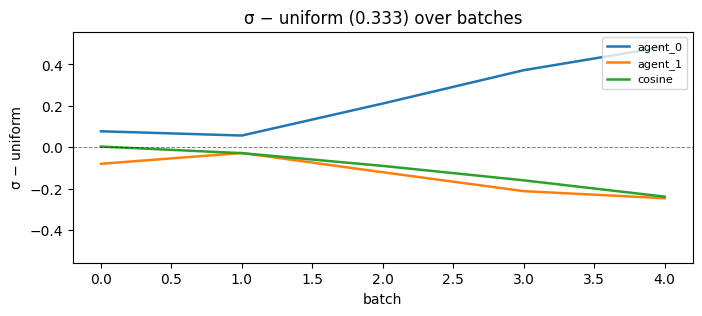

In [7]:
plot_sigma(fb_history);


### Judge / impute coverage

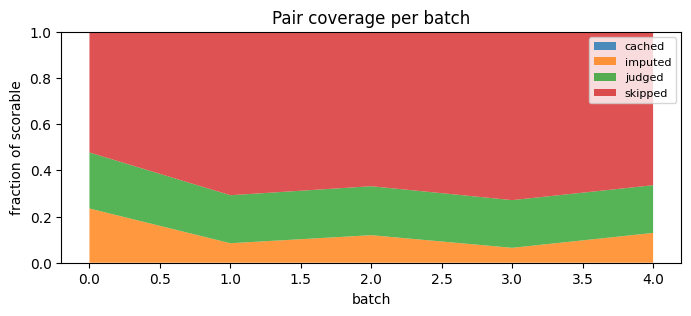

In [8]:
plot_coverage(fb_history);


### Per-agent meta-reward (surprisal credit)

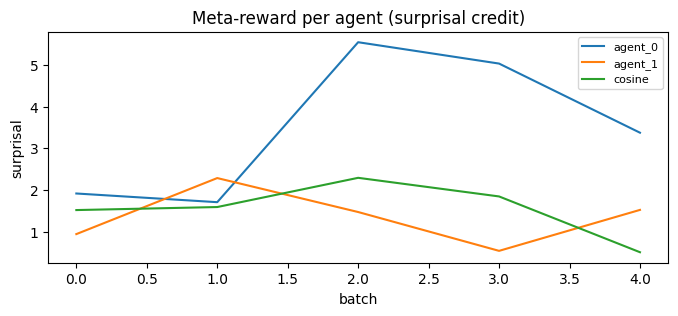

In [9]:
plot_meta_rewards(fb_history);


## The graph itself

Spring layout. Green = coherent (+w), red = contradictory (−w), width by |w|.

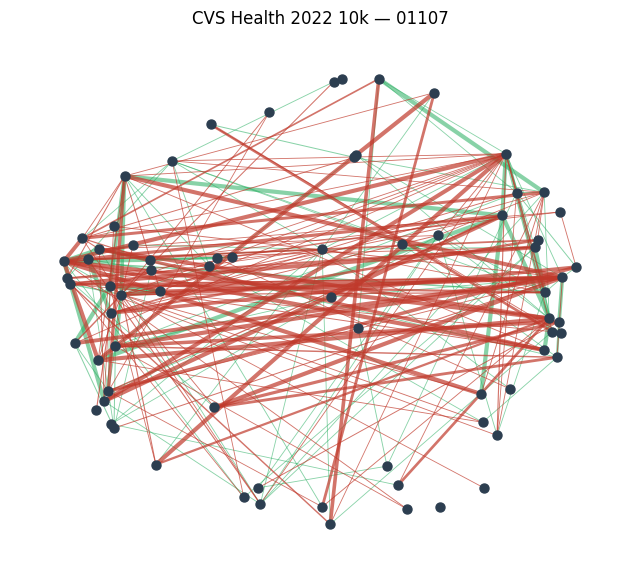

In [10]:
plot_belief_graph(fb_graph, fb_node_texts, title=f"{question.label} — {question.qid[-5:]}");


## Strongest pairs

In [11]:
coh, dis = top_edges(fb_graph, fb_node_texts, n=5)
print("Top coherent (+w):")
for a, b, w in coh:
    print(f"  +{w:.2f}")
    print(f"    A: {a}")
    print(f"    B: {b}\n")
if dis:
    print("\nTop contradictory (−w):")
    for a, b, w in dis:
        print(f"  {w:+.2f}")
        print(f"    A: {a}")
        print(f"    B: {b}\n")
else:
    print("\n(no contradictory edges this run)")


Top coherent (+w):
  +1.00
    A: In November 2021, a jury in a trial in federal court in Ohio found CVS Health liable among chain pharmacies regarding opioid-related claims.
    B: CVS Health is being investigated by Attorneys General of several states and the District of Columbia regarding its PBM practices, including pricing and rebates.

  +1.00
    A: Under the December 2022 formal settlement agreement with state Attorneys General and the PEC, the maximum amount payable by CVS Health for opioid remediation would be approximately $4.3 billion.
    B: During the three months ended March 31, 2022, CVS Health recorded a $484 million liability associated with the March 2022 settlement with the State of Florida.

  +1.00
    A: The December 2022 formal settlement agreement with state Attorneys General and the PEC is available at nationalopioidsettlement.com.
    B: CVS Health has not accrued a liability for the August 2022 $651 million judgment.

  +1.00
    A: The amounts from the Dece

## Inference: route the question through each role

After training, embed the question text with the same sentence-transformer used for the beliefs and ask each agent to rank graph nodes against it. The three rankings show:

- **`semantic`** (cosine baseline): which beliefs are simply most similar to the question.
- **`coherence`** (`agent_0`, trained for +y): which beliefs the coherence head wants to surface — direct evidentiary support.
- **`contradiction`** (`agent_1`, trained for −y): which beliefs the contradiction head surfaces — the conflicting / counterfactual side.

Edit `INFER_QUERY` to ask anything you like.

In [12]:
from sentence_transformers import SentenceTransformer

_emb_model = SentenceTransformer("all-MiniLM-L6-v2")

INFER_QUERY = question.question
query_emb = np.asarray(
    _emb_model.encode(INFER_QUERY, normalize_embeddings=True), dtype=np.float32
)

ranking = trainer.rank(query_emb, k=8)
_role_of = {a.agent_id: getattr(a, "role", None) for a in trainer.population.agents}

print(f"QUERY: {INFER_QUERY}\n")
for aid, items in ranking.items():
    role = _role_of.get(aid) or "—"
    print(f"=== {aid}  ({role}) ===")
    for nid, s in items:
        print(f"  {s:+.3f}  {fb_node_texts.get(nid, nid)}")
    print()


Loading weights: 100%|█| 103/103 [00:00<00:0


QUERY: Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?

=== agent_0  (coherence) ===
  +0.655  The financial amounts for the December 2022 formal settlement agreement with state Attorneys General and the PEC were agreed to in principle in October 2022.
  +0.570  The $484 million settlement amount from the March 2022 agreement with the State of Florida is to be paid over a period of 18 years.
  +0.491  The December 2022 formal settlement agreement with state Attorneys General and the PEC is available at nationalopioidsettlement.com.
  +0.463  CVS Health has not accrued a liability for the August 2022 $651 million judgment.
  +0.456  The December 2022 formal settlement agreement with state Attorneys General and the PEC contemplates a corresponding reduction in the amount due from CVS Health if certain governmental entities do not agree but CVS Health proceeds with the settlement.
  +0.437  Governmental entities not participating in the Dec